# A lead is a claim about a lag, and a lag has to be estimated

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/leading-indicator-finder/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/leading-indicator-finder/demo.ipynb)

*"We find out a month too late."* So somebody builds a table of candidate
leading indicators, correlates each one against revenue at a few lags, sorts by
the biggest number and puts the top three on a dashboard.

This notebook builds a world where the true lead of every candidate is known,
runs that procedure on it, and grades it.

**What it covers**

1. A funnel where the lead, the lag and the causal gain of each metric are known
2. Why the earliest warning is always the weakest signal
3. Four rankers, one world, four different answers
4. The peak of the cross-correlation function is not a lead
5. Change the horizon and the shortlist reverses
6. Predicting revenue and being able to move it are different properties
7. A world containing nothing, scanned six ways
8. What the table should have said

Everything runs on numpy, scipy, pandas and matplotlib. No API keys, no data files.

## 1. A world where the lead is known

Goodhart-free, drift-free, and deliberately generous: revenue really is driven by
an upstream funnel, and three of the candidates really do lead it.

```
a_t = phi*a_{t-1} + eps            latent demand
s_t = c_s*a_{t-1} + eps            signups
v_t = c_v*s_{t-1} + eps            activations
y_t = c_y*v_{t-1} + season + eps   revenue
```

Revenue at `t` is driven by demand at `t-3`, so awareness leads by 3, signups by
2 and activations by 1. Around the funnel sit six metrics that correlate with
revenue and carry nothing usable: a **sensor** that reads demand without being
part of the chain, a metric that **follows** revenue, a metric that shares only a
**calendar**, a **random walk**, and two unrelated AR(1) series.

In [1]:
from __future__ import annotations

from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
from scipy import stats

PHI, C_S, C_V, C_Y = 0.75, 0.80, 0.80, 0.80
SD_A = SD_NOISE = 1.00
SD_S = SD_V = 0.55
SD_Y = 0.60
PERIOD, T, BURN = 12, 240, 120

CANDIDATES = ["web_sessions", "awareness_index", "signups", "activations",
              "support_tickets", "marketing_spend", "nps_trend",
              "placebo_1", "placebo_2", "placebo_3"]

# The two properties no ranker is allowed to see.
TRUE_LEAD = {"web_sessions": 3, "awareness_index": 3, "signups": 2, "activations": 1,
             "support_tickets": -1, "marketing_spend": 0, "nps_trend": 0,
             "placebo_1": 0, "placebo_2": 0, "placebo_3": 0}
GAIN = {c: 0.0 for c in CANDIDATES}
GAIN["signups"], GAIN["activations"] = C_V * C_Y, C_Y     # revenue per unit pushed
INFORMATIVE = ["web_sessions", "awareness_index", "signups", "activations"]


def season(t: np.ndarray, period: int = PERIOD) -> np.ndarray:
    x = 2.0 * np.pi * t / period
    return np.sin(x) + 0.35 * np.sin(2.0 * x + 0.7)


def simulate(seed: int = 20260902, sd_web: float = 0.30, n_obs: int = T,
             force: Optional[Tuple[str, float]] = None) -> Dict[str, np.ndarray]:
    """One run. `force=(metric, delta)` is the do-operator: the metric is shifted
    before anything downstream reads it, so a funnel stage propagates and a
    sensor does not."""
    rng = np.random.default_rng(seed)
    n = n_obs + BURN
    name, delta = force if force is not None else ("", 0.0)
    ea, es, ev, ey = (rng.normal(size=n) for _ in range(4))
    sy = 1.20 * season(np.arange(n))
    a = np.zeros(n); s = np.zeros(n); v = np.zeros(n); y = np.zeros(n)
    for t in range(1, n):
        a[t] = PHI * a[t - 1] + SD_A * ea[t]
        s[t] = C_S * a[t - 1] + SD_S * es[t] + (delta if name == "signups" else 0.0)
        v[t] = C_V * s[t - 1] + SD_V * ev[t] + (delta if name == "activations" else 0.0)
        y[t] = C_Y * v[t - 1] + sy[t] + SD_Y * ey[t]
    # Draw order matters: it is kept identical to leadlag.py so that every
    # number this notebook prints is the number evidence.py prints.
    web = 0.95 * a + sd_web * rng.normal(size=n)
    aware = 0.90 * a + 0.60 * rng.normal(size=n)
    tick = np.zeros(n); tick[1:] = 0.80 * y[:-1] + 0.40 * rng.normal(size=n - 1)
    mkt = 1.60 * season(np.arange(n) + 1) + 0.50 * rng.normal(size=n)
    nps = np.cumsum(rng.normal(size=n) * 0.35)
    out = {"revenue": y, "signups": s, "activations": v, "support_tickets": tick,
           "web_sessions": web, "awareness_index": aware,
           "marketing_spend": mkt, "nps_trend": nps}
    for i in range(1, 4):
        z = np.zeros(n); e = rng.normal(size=n)
        for t in range(1, n):
            z[t] = 0.60 * z[t - 1] + SD_NOISE * e[t]
        out[f"placebo_{i}"] = z
    if name in out and name not in ("signups", "activations"):
        out[name] = out[name] + delta          # a sensor can only be re-labelled
    return {k: val[BURN:] for k, val in out.items()}


d = simulate()
print(f"{len(d['revenue'])} months of revenue, {len(CANDIDATES)} candidates")
print(f"revenue mean {d['revenue'].mean():.2f}, sd {d['revenue'].std():.2f}")

240 months of revenue, 10 candidates
revenue mean 0.11, sd 1.50


## 2. Warning time is bought with signal, and with leverage

Each funnel stage passes on a fraction of the one before it. So the stage that
warns earliest is also the one least correlated with revenue **and** the one with
the least leverage over it. Ranking candidates by strength prefers the metric
that gives the least warning - and that is arithmetic, not a flaw in any tool.

In [2]:
def lagged_corr(x: np.ndarray, y: np.ndarray, lag: int) -> float:
    """Positive lag = x is read earlier than y, i.e. x leads."""
    if lag > 0:
        xa, ya = x[:-lag], y[lag:]
    elif lag < 0:
        xa, ya = x[-lag:], y[:lag]
    else:
        xa, ya = x, y
    if xa.size < 8 or np.std(xa) == 0 or np.std(ya) == 0:
        return 0.0
    return float(np.corrcoef(xa, ya)[0, 1])


funnel = pd.DataFrame([
    {"metric": c, "months of warning": TRUE_LEAD[c],
     "r with revenue": round(lagged_corr(d[c], d["revenue"], TRUE_LEAD[c]), 3),
     "revenue per unit pushed": GAIN[c]}
    for c in ["activations", "signups", "web_sessions"]
])
print(funnel.to_string(index=False))
print("\nThe longest warning is the weakest signal AND the smallest lever.")

      metric  months of warning  r with revenue  revenue per unit pushed
 activations                  1           0.709                     0.80
     signups                  2           0.670                     0.64
web_sessions                  3           0.612                     0.00

The longest warning is the weakest signal AND the smallest lever.


## 3. Four rankers, one world, four answers

- **lead-scan**: the strongest positive-lag correlation over lags 1-12.
- **|CCF| peak**: the biggest correlation at *any* lag, negative ones included.
  This is what a scan written without sign discipline does.
- **prewhitened**: strip the two annual harmonics and the level first (Box-Jenkins).
- **Granger**: does the candidate's history reduce revenue's residual variance
  *given revenue's own history*? Raw correlation cannot answer this.

In [3]:
def corr_profile(x, y, lags):
    return {k: lagged_corr(x, y, k) for k in lags}


def rank_lead(x, y, max_lag=12):
    p = corr_profile(x, y, range(1, max_lag + 1)); k = max(p, key=lambda i: p[i]); return p[k], k


def rank_abs_sym(x, y, max_lag=12):
    p = corr_profile(x, y, range(-max_lag, max_lag + 1))
    k = max(p, key=lambda i: abs(p[i])); return p[k], k


def _design(cols): return np.column_stack([np.ones(len(cols[0]))] + cols)


def _rss(X, y):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None); r = y - X @ beta; return beta, float(r @ r)


def harmonics(idx, period=PERIOD):
    sx = 2.0 * np.pi * idx / period
    return [np.sin(sx), np.cos(sx), np.sin(2 * sx), np.cos(2 * sx)]


def granger_p(x, y, p=4):
    n = len(y); rows = slice(p, n)
    ylags = [y[p - k: n - k] for k in range(1, p + 1)]
    xlags = [x[p - k: n - k] for k in range(1, p + 1)]
    ex = harmonics(np.arange(n)[rows]); tgt = y[rows]
    _, rr = _rss(_design(ylags + ex), tgt)
    _, rf = _rss(_design(ylags + xlags + ex), tgt)
    dfd = len(tgt) - (1 + 2 * p + len(ex))
    f = ((rr - rf) / p) / (rf / dfd)
    return float(stats.f.sf(f, p, dfd))


def deseasonalize(z, period=PERIOD):
    X = _design(harmonics(np.arange(len(z)), period)); beta, _ = _rss(X, z); return z - X @ beta


def rank_prewhitened(x, y):
    return rank_lead(np.diff(deseasonalize(x)), np.diff(deseasonalize(y)))


rows = []
for c in CANDIDATES:
    r1, l1 = rank_lead(d[c], d["revenue"]); r2, l2 = rank_abs_sym(d[c], d["revenue"])
    r3, l3 = rank_prewhitened(d[c], d["revenue"])
    rows.append({"metric": c, "lead-scan r": round(r1, 3), "lag": l1,
                 "|CCF| peak r": round(r2, 3), "peak lag": l2,
                 "prewhitened r": round(r3, 3), "Granger p": f"{granger_p(d[c], d['revenue']):.2g}"})
ranking = pd.DataFrame(rows).sort_values("|CCF| peak r", key=abs, ascending=False)  # noqa: E501
print(ranking.to_string(index=False))
top = ranking.iloc[0]
print(f"\nThe |CCF| peak crowns '{top['metric']}' at r={top['|CCF| peak r']:+.3f}, "
      f"lag {int(top['peak lag'])} - a metric that FOLLOWS revenue.")

         metric  lead-scan r  lag  |CCF| peak r  peak lag  prewhitened r Granger p
support_tickets        0.365    1         0.955        -1          0.122      0.37
    activations        0.709    1         0.709         1          0.764   2.2e-60
        signups        0.670    2         0.670         2          0.620   1.2e-38
   web_sessions        0.612    3         0.612         3          0.417   1.5e-24
awareness_index        0.605    3         0.605         3          0.400   1.3e-21
marketing_spend        0.596    1         0.596         1          0.208       0.1
      placebo_1        0.194    4        -0.326        11          0.105      0.18
      placebo_3        0.222    8         0.222         8          0.099      0.63
      nps_trend       -0.029   12        -0.156       -10          0.108      0.16
      placebo_2        0.067    9         0.093        -8          0.124       0.9

The |CCF| peak crowns 'support_tickets' at r=+0.955, lag -1 - a metric that FOLLOWS re

## 4. The peak of the cross-correlation function is not a lead

Support tickets are caused *by* revenue a month later. Their correlation with
revenue is 0.95 - higher than any real indicator here - and it sits at lag **-1**.
Anything that takes the biggest absolute correlation over a symmetric lag window
reports a follower as the strongest leading indicator in the business.

Respecting the sign helps, but not enough: revenue is persistent, so a metric
tracking last month's revenue also tracks this month's, and support tickets still
post r = +0.37 at lag +1. Only conditioning on revenue's own history kills it
(Granger p = 0.37).

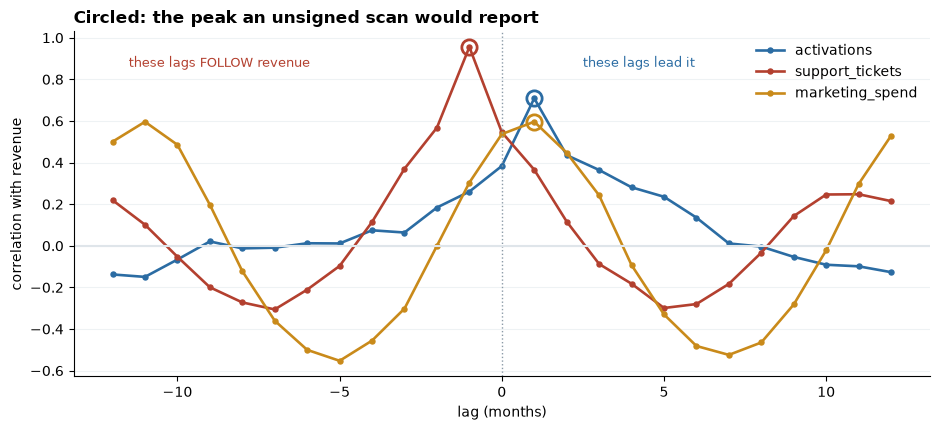

In [4]:
import matplotlib.pyplot as plt

lags = list(range(-12, 13))
fig, ax = plt.subplots(figsize=(9.5, 4.4))
for name, col in (("activations", "#2b6ca3"), ("support_tickets", "#b3402f"),
                  ("marketing_spend", "#c98a1a")):
    prof = [lagged_corr(d[name], d["revenue"], k) for k in lags]
    ax.plot(lags, prof, "-o", ms=3.6, lw=1.9, color=col, label=name)
    k = int(np.argmax(np.abs(prof)))
    ax.plot([lags[k]], [prof[k]], "o", ms=11, mfc="none", mec=col, mew=2)
ax.axvline(0, color="#8b9aa7", ls=":", lw=1); ax.axhline(0, color="#dfe5ea")
ax.text(-11.5, 0.86, "these lags FOLLOW revenue", color="#b3402f", fontsize=9)
ax.text(2.5, 0.86, "these lags lead it", color="#2b6ca3", fontsize=9)
ax.set_xlabel("lag (months)"); ax.set_ylabel("correlation with revenue")
ax.set_title("Circled: the peak an unsigned scan would report", loc="left", fontweight="bold")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False); ax.grid(axis="y", color="#eef2f4"); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("ccf_both_signs.png", dpi=150); plt.show()

## 5. Change the horizon and the shortlist reverses

Standing in month `t` we know revenue and every candidate up to `t`. Forecasting
`h` months ahead can therefore only use candidate readings at lags of `h` or
more - a metric whose lead is shorter than the horizon **cannot be read early
enough to help**, however strongly it correlates.

The test below is a rolling-origin backtest against revenue's own history (three
lags plus two annual harmonics), because "does it correlate" is not the question -
"does it beat what we already know" is. The lag is re-chosen on each training
window; choosing it once on the full series is the leak that makes everything
look useful.

In [5]:
def diebold_mariano(e1, e2):
    """Is the RMSE difference bigger than the noise in the difference?"""
    dd = np.square(e1) - np.square(e2); n = len(dd); dbar = float(np.mean(dd))
    lag = max(1, int(round(n ** (1 / 3)))); var = float(np.mean((dd - dbar) ** 2))
    for k in range(1, lag + 1):
        var += 2 * (1 - k / (lag + 1)) * float(np.mean((dd[k:] - dbar) * (dd[:-k] - dbar)))
    return 1.0 if var <= 0 else float(stats.norm.sf(dbar / np.sqrt(var / n)))


def oos_gain(y, x, h, max_lag=12, min_train=96, p=3):
    n = len(y); harm = harmonics(np.arange(n)); lags = list(range(max(h, 1), max_lag + 1))
    eb, ea = [], []
    for origin in range(min_train, n - h):
        tr = np.arange(p, origin - h + 1)
        if tr.size < 40:
            continue
        ytr = y[tr + h]
        base = [y[tr - k] for k in range(0, p)] + [c[tr + h] for c in harm]
        beta_b, _ = _rss(_design(base), ytr)
        best, best_rss = lags[0], np.inf
        for lag in lags:                        # chosen on the TRAINING window only
            _, rss = _rss(_design(base + [x[tr + h - lag]]), ytr)
            if rss < best_rss:
                best_rss, best = rss, lag
        beta_a, _ = _rss(_design(base + [x[tr + h - best]]), ytr)
        row_b = np.array([1.0] + [y[origin - k] for k in range(0, p)] + [c[origin + h] for c in harm])
        eb.append(y[origin + h] - row_b @ beta_b)
        ea.append(y[origin + h] - np.append(row_b, x[origin + h - best]) @ beta_a)
    eb, ea = np.array(eb), np.array(ea)
    rb, ra = np.sqrt(np.mean(eb ** 2)), np.sqrt(np.mean(ea ** 2))
    return {"gain_pct": 100 * (rb - ra) / rb, "dm_p": diebold_mariano(eb, ea)}


oos = {h: {c: oos_gain(d["revenue"], d[c], h) for c in CANDIDATES} for h in (1, 3)}
tbl = pd.DataFrame([{"metric": c,
                     "h=1 gain %": round(oos[1][c]["gain_pct"], 2), "h=1 DM p": round(oos[1][c]["dm_p"], 3),
                     "h=3 gain %": round(oos[3][c]["gain_pct"], 2), "h=3 DM p": round(oos[3][c]["dm_p"], 3)}
                    for c in CANDIDATES]).sort_values("h=3 gain %", ascending=False)
print(tbl.to_string(index=False))
rho = stats.spearmanr([oos[1][c]["gain_pct"] for c in INFORMATIVE],
                      [oos[3][c]["gain_pct"] for c in INFORMATIVE]).statistic
print(f"\nBest at h=1: {max(CANDIDATES, key=lambda c: oos[1][c]['gain_pct'])}")
print(f"Best at h=3: {max(CANDIDATES, key=lambda c: oos[3][c]['gain_pct'])}")
print(f"Spearman between the two rankings over the four informative candidates: {rho:+.2f}")

         metric  h=1 gain %  h=1 DM p  h=3 gain %  h=3 DM p
   web_sessions       21.49     0.000       27.25     0.000
awareness_index       17.24     0.000       23.84     0.000
        signups       32.00     0.000       13.66     0.000
      placebo_1       -0.69     0.684        1.79     0.220
    activations       47.99     0.000        1.76     0.256
support_tickets       -0.04     0.510        0.77     0.347
marketing_spend        0.03     0.488       -0.52     0.690
      nps_trend       -0.73     0.731       -1.89     0.776
      placebo_3       -1.33     0.953       -2.08     0.868
      placebo_2       -1.86     0.963       -2.73     0.976

Best at h=1: activations
Best at h=3: web_sessions
Spearman between the two rankings over the four informative candidates: -0.80


`activations` is the strongest correlate in the business and adds **nothing** at a
three-month horizon: it leads by one month, so it is not available in time.
`web_sessions` is the weakest of the three real signals and wins outright.

Note also that a placebo posts a *positive* percentage. A positive gain is not a
finding - the test on the loss differential is.

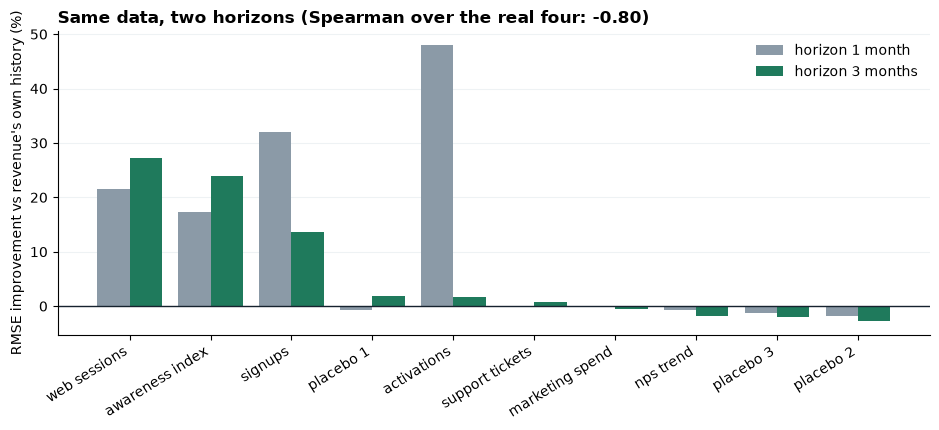

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
order = list(tbl["metric"])
x = np.arange(len(order))
ax.bar(x - 0.2, [oos[1][c]["gain_pct"] for c in order], 0.4, color="#8b9aa7", label="horizon 1 month")
ax.bar(x + 0.2, [oos[3][c]["gain_pct"] for c in order], 0.4, color="#1f7a5c", label="horizon 3 months")
ax.axhline(0, color="#16222e", lw=1)
ax.set_xticks(x); ax.set_xticklabels([c.replace("_", " ") for c in order], rotation=32, ha="right")
ax.set_ylabel("RMSE improvement vs revenue's own history (%)")
ax.set_title(f"Same data, two horizons (Spearman over the real four: {rho:+.2f})",
             loc="left", fontweight="bold")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False); ax.grid(axis="y", color="#eef2f4"); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("horizon_reversal.png", dpi=150); plt.show()

## 6. Predicting revenue and being able to move it are different properties

`web_sessions` wins the horizon-matched backtest. It is a **sensor**: it reads
demand without being part of the chain, so there is nothing downstream of it to
push. The do-operator settles it - add 1.0 to a metric at every period, before
anything downstream reads it, and measure revenue. Common random numbers, so the
comparison carries no sampling noise.

In [7]:
eff = {}
for c in CANDIDATES:
    deltas = [simulate(seed=5000 + s, force=(c, 1.0))["revenue"].mean()
              - simulate(seed=5000 + s)["revenue"].mean() for s in range(8)]
    eff[c] = float(np.mean(deltas))

truth = pd.DataFrame([{"metric": c, "h=3 gain %": round(oos[3][c]["gain_pct"], 2),
                       "dY/dX measured": round(eff[c], 3), "closed form": GAIN[c],
                       "months of warning": TRUE_LEAD[c]}
                      for c in CANDIDATES]).sort_values("h=3 gain %", ascending=False)
print(truth.to_string(index=False))
best = max(CANDIDATES, key=lambda c: oos[3][c]["gain_pct"])
print(f"\nBest indicator at h=3 is '{best}', and moving it changes revenue by {eff[best]:.3f}.")
print(f"The biggest lever is 'activations' ({eff['activations']:.2f} per unit) - "
      f"and it warns {TRUE_LEAD['activations']} month ahead.")
print("\nNothing observational separates those two columns.")

         metric  h=3 gain %  dY/dX measured  closed form  months of warning
   web_sessions       27.25            0.00         0.00                  3
awareness_index       23.84            0.00         0.00                  3
        signups       13.66            0.64         0.64                  2
      placebo_1        1.79            0.00         0.00                  0
    activations        1.76            0.80         0.80                  1
support_tickets        0.77            0.00         0.00                 -1
marketing_spend       -0.52            0.00         0.00                  0
      nps_trend       -1.89            0.00         0.00                  0
      placebo_3       -2.08            0.00         0.00                  0
      placebo_2       -2.73            0.00         0.00                  0

Best indicator at h=3 is 'web_sessions', and moving it changes revenue by 0.000.
The biggest lever is 'activations' (0.80 per unit) - and it warns 1 month ahead.



## 7. A world containing nothing, scanned six ways

Revenue that is persistent and seasonal, because real revenue is. Ten candidates
drawn independently of it. Any indicator found here is false by construction, so
the rate at which a method finds one is that method's false-positive rate -
measured, not nominal.

In [8]:
def ac1(z): return lagged_corr(z, z, 1)


def naive_p(r, n):
    if n <= 3 or abs(r) >= 1:
        return 0.0 if abs(r) >= 1 else 1.0
    return float(2 * stats.t.sf(abs(r * np.sqrt((n - 2) / max(1e-12, 1 - r * r))), n - 2))


def bartlett_p(r, n, rx, ry):
    """Two autocorrelated series share fewer independent facts than they have rows."""
    rho = float(np.clip(rx * ry, -0.99, 0.99))
    return naive_p(r, int(round(max(4.0, n * (1 - rho) / (1 + rho)))))


def null_world(seed, n=120, k=10):
    rng = np.random.default_rng(seed); y = np.zeros(n); e = rng.normal(size=n)
    for i in range(1, n):
        y[i] = 0.70 * y[i - 1] + e[i]
    y = y + 1.20 * season(np.arange(n))
    X = np.zeros((k, n))
    for j in range(k):
        z = np.zeros(n); ez = rng.normal(size=n)
        for i in range(1, n):
            z[i] = 0.60 * z[i - 1] + ez[i]
        X[j] = z
    return y, X


REPS, ALPHA, MAXLAG = 150, 0.05, 12
acc = {k: 0 for k in ["one test, textbook p", "best of 10 x 12, textbook p",
                      "best of 10 x 12, Bonferroni", "best of 10 x 12, Bartlett",
                      "best of 10 x 12, Bartlett + Bonferroni",
                      "Granger, best of 10", "Granger, best of 10 + Bonferroni"]}
for s in range(REPS):
    y, X = null_world(90000 + s); ry = ac1(y); n = len(y)
    pn, pb, pg = 1.0, 1.0, 1.0
    for j, x in enumerate(X):
        rx = ac1(x)
        if j == 0 and naive_p(lagged_corr(x, y, 3), n - 3) < ALPHA:
            acc["one test, textbook p"] += 1
        pg = min(pg, granger_p(x, y))
        for lag in range(1, MAXLAG + 1):
            r = lagged_corr(x, y, lag)
            pn = min(pn, naive_p(r, n - lag)); pb = min(pb, bartlett_p(r, n - lag, rx, ry))
    m = 10 * MAXLAG
    acc["best of 10 x 12, textbook p"] += pn < ALPHA
    acc["best of 10 x 12, Bonferroni"] += pn < ALPHA / m
    acc["best of 10 x 12, Bartlett"] += pb < ALPHA
    acc["best of 10 x 12, Bartlett + Bonferroni"] += pb < ALPHA / m
    acc["Granger, best of 10"] += pg < ALPHA
    acc["Granger, best of 10 + Bonferroni"] += pg < ALPHA / 10

rates = {k: v / REPS for k, v in acc.items()}
for k, v in rates.items():
    print(f"  {k:<42} {v:.3f}")
print(f"\nNominal for every row: {ALPHA:.3f}. "
      f"A calibrated 5% test over 10 candidates would give {1 - 0.95 ** 10:.3f}.")

  one test, textbook p                       0.173
  best of 10 x 12, textbook p                1.000
  best of 10 x 12, Bonferroni                0.640
  best of 10 x 12, Bartlett                  0.887
  best of 10 x 12, Bartlett + Bonferroni     0.007
  Granger, best of 10                        0.433
  Granger, best of 10 + Bonferroni           0.033

Nominal for every row: 0.050. A calibrated 5% test over 10 candidates would give 0.401.


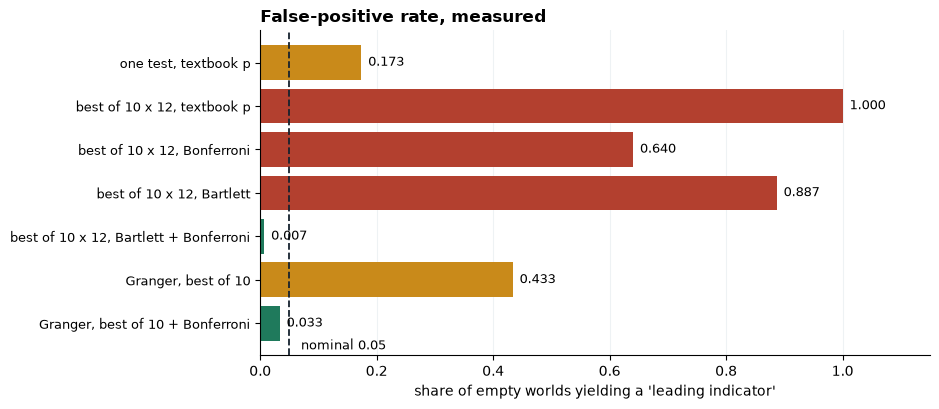

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
keys = list(rates); vals = [rates[k] for k in keys]
cols = ["#b3402f" if v > 0.5 else ("#c98a1a" if v > 0.10 else "#1f7a5c") for v in vals]
ax.barh(np.arange(len(keys)), vals, color=cols)
ax.set_yticks(np.arange(len(keys))); ax.set_yticklabels(keys, fontsize=9); ax.invert_yaxis()
ax.axvline(0.05, color="#16222e", ls="--", lw=1.3)
ax.text(0.07, len(keys) - 0.4, "nominal 0.05", fontsize=9)
for i, v in enumerate(vals):
    ax.text(v + 0.012, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.15); ax.set_xlabel("share of empty worlds yielding a 'leading indicator'")
ax.set_title("False-positive rate, measured", loc="left", fontweight="bold")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="x", color="#eef2f4"); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("null_false_positive.png", dpi=150); plt.show()

The correlation scan finds a leading indicator in **every** empty world. And it
is not mainly the scanning: one candidate at one pre-registered lag already
fires far above 5%, because the textbook p-value assumes 120 rows are 120
independent facts, and two autocorrelated series are nothing like that.

Bonferroni fixes the multiplicity and leaves most of the problem. A Bartlett
effective-sample correction fixes the autocorrelation and leaves most of the
problem. Each looks adequate on its own; only together do they land below nominal.

**Granger is a different story.** Conditioning on revenue's own lags removes the
autocorrelation at the source, so it arrives already calibrated - its rate over
ten candidates is close to what a perfect 5% test would give over ten tries, and
Bonferroni finishes the job. The cheap screen is Granger plus Bonferroni, not a
cross-correlation table.

## 8. What the table should have said

The correlation column changed nothing. The horizon column changed the answer.
The column that changes the plan is not in the data at all.

In [10]:
final = pd.DataFrame([{
    "metric": c,
    "r@lag": round(rank_lead(d[c], d["revenue"])[0], 3),
    "Granger p": f"{granger_p(d[c], d['revenue']):.2g}",
    "OOS gain % (h=3)": round(oos[3][c]["gain_pct"], 2),
    "DM p": round(oos[3][c]["dm_p"], 3),
    "verdict": ("watch AND pull" if oos[3][c]["dm_p"] < 0.05 and GAIN[c] > 0 else
                "watch, cannot pull" if oos[3][c]["dm_p"] < 0.05 and oos[3][c]["gain_pct"] > 0 else
                "correlated, no lead value" if rank_lead(d[c], d["revenue"])[0] > 0.30 else "drop"),
} for c in CANDIDATES]).sort_values("OOS gain % (h=3)", ascending=False)
print(final.to_string(index=False))
corr30 = int((final["r@lag"] > 0.30).sum())
kept = final[final["verdict"].str.startswith("watch")]
print(f"\n{corr30} of 10 candidates correlate with future revenue above 0.30.")
print(f"{len(kept)} survive a horizon-matched backtest.")
print(f"{sum(GAIN[c] > 0 for c in kept['metric'])} of those can actually be moved.")

         metric  r@lag Granger p  OOS gain % (h=3)  DM p                   verdict
   web_sessions  0.612   1.5e-24             27.25 0.000        watch, cannot pull
awareness_index  0.605   1.3e-21             23.84 0.000        watch, cannot pull
        signups  0.670   1.2e-38             13.66 0.000            watch AND pull
      placebo_1  0.194      0.18              1.79 0.220                      drop
    activations  0.709   2.2e-60              1.76 0.256 correlated, no lead value
support_tickets  0.365      0.37              0.77 0.347 correlated, no lead value
marketing_spend  0.596       0.1             -0.52 0.690 correlated, no lead value
      nps_trend -0.029      0.16             -1.89 0.776                      drop
      placebo_3  0.222      0.63             -2.08 0.868                      drop
      placebo_2  0.067       0.9             -2.73 0.976                      drop

6 of 10 candidates correlate with future revenue above 0.30.
3 survive a horizon-match

## Try your own

Uncomment and re-run. Each line changes a claim above.

In [11]:
# --- 1. A five-year history instead of twenty. Does the lag survive?
# small = simulate(n_obs=60)
# print(rank_lead(small["web_sessions"], small["revenue"]))

# --- 2. A noisy sensor. Below r ~ 0.33 the reported lag is mostly a draw
#        from the 12-lag grid.
# hits = []
# for s in range(200):
#     w = simulate(seed=8000 + s, sd_web=9.0, n_obs=60)
#     r, lag = rank_lead(w["web_sessions"], w["revenue"])
#     hits.append(lag == 3)
# print("true lag recovered:", np.mean(hits))

# --- 3. The horizon you actually need. Six months of warning leaves what?
# for c in INFORMATIVE:
#     print(c, round(oos_gain(d["revenue"], d[c], 6)["gain_pct"], 2))

# --- 4. Your own candidate. Give it a lead and see what the rankers say.
# mine = np.roll(d["_demand"] if "_demand" in d else d["web_sessions"], 0)
# print(rank_lead(mine, d["revenue"]), granger_p(mine, d["revenue"]))

## What to take away

1. **Never rank by the peak of the cross-correlation function.** It has no sign
   discipline, and a metric that *follows* your KPI will win it.
2. **Rank at the horizon you need warning over.** A one-month indicator cannot
   help a three-month decision, and at three months the shortlist here reverses
   (Spearman -0.80).
3. **Score against the KPI's own history**, not against zero. Anything else
   rewards persistence you already had.
4. **A positive percentage is not a finding.** Test the loss differential.
5. **Screen with Granger plus Bonferroni**, not a correlation table. The
   correlation scan finds an indicator in 100% of empty worlds; both corrections
   are needed to bring that below nominal, while Granger is calibrated already.
6. **The lag is the easy part** when the signal is real - and unreadable when it
   is weak. Publish the peak correlation next to the lag so a reader can tell
   which case they are in.
7. **A scan is a forecast, never a plan.** The best forecaster here has a causal
   gain of exactly zero, and the biggest lever gives the least warning.

---

**Day 163 of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) portfolio.**

- Full evidence run with every number: [`evidence.py`](evidence.py)
- 34 assertions over the claims: [`test_leadlag.py`](test_leadlag.py)
- Interactive version: `streamlit run app.py`
- Six-panel figure: [`lead_lag_audit.png`](lead_lag_audit.png)